# Task 3: Data Cleaning

## Titanic Dataset

### Objective

The objective of this project is to identify and correct data quality issues in the Titanic dataset and prepare a clean dataset suitable for further analysis.

The cleaning process includes:

- Inspecting the dataset
- Identifying missing values
- Detecting duplicate records
- Checking inconsistent values
- Correcting data types
- Checking invalid or unrealistic values
- Detecting outliers using the IQR method
- Applying appropriate cleaning techniques
- Comparing the dataset before and after cleaning
- Exporting the cleaned dataset as a new CSV file

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_original = df.copy()

print("Original dataset stored successfully.")

Original dataset stored successfully.


## 1. Initial Dataset Inspection

Before cleaning the dataset, its dimensions, column names, data types, statistical information, missing values, and duplicate records are examined.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [6]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2. Descriptive Statistics

Descriptive statistics are used to understand the numerical variables before cleaning.

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Data Quality Report

A data quality report is created to identify missing values, unique values, and data types for each column.

In [9]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Unique Values
PassengerId,int64,0,891
Survived,int64,0,2
Pclass,int64,0,3
Name,object,0,891
Sex,object,0,2
Age,float64,177,88
SibSp,int64,0,7
Parch,int64,0,7
Ticket,object,0,681
Fare,float64,0,248


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_report

,Missing Values,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


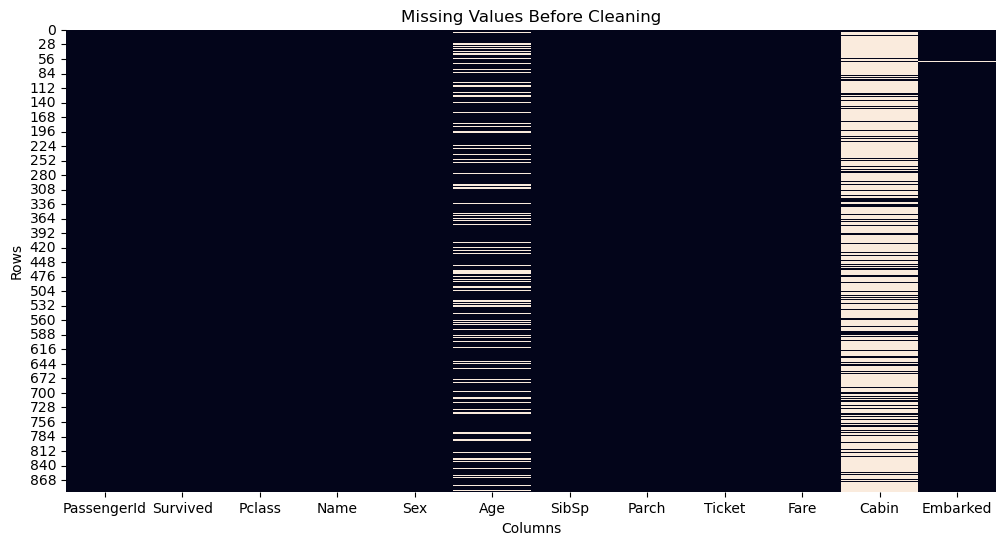

In [12]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

## 4. Duplicate Record Analysis

Duplicate rows can result in incorrect analysis because the same passenger may be counted more than once. Therefore, duplicate records are checked before cleaning.

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [15]:
before_rows = df.shape[0]
before_columns = df.shape[1]
before_missing = df.isnull().sum().sum()
before_duplicates = df.duplicated().sum()

print("Rows before cleaning:", before_rows)
print("Columns before cleaning:", before_columns)
print("Missing values before cleaning:", before_missing)
print("Duplicate rows before cleaning:", before_duplicates)

Rows before cleaning: 891
Columns before cleaning: 12
Missing values before cleaning: 866
Duplicate rows before cleaning: 0


## 5. Inconsistent Formatting Analysis

Categorical columns are checked for inconsistent capitalization and unnecessary whitespace.

In [16]:
print("Sex values:")
print(df["Sex"].value_counts())

print("\nEmbarked values:")
print(df["Embarked"].value_counts())

Sex values:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked values:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [17]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [18]:
for column in text_columns:
    print(column, ":", df[column].nunique(), "unique values")

Name : 891 unique values
Sex : 2 unique values
Ticket : 681 unique values
Cabin : 147 unique values
Embarked : 3 unique values


In [19]:
df["Sex"] = df["Sex"].str.lower().str.strip()

In [20]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [21]:
df["Embarked"] = df["Embarked"].str.upper().str.strip()

In [22]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [24]:
age_median = df["Age"].median()

df["Age"] = df["Age"].fillna(age_median)

print("Missing Age values after cleaning:", df["Age"].isnull().sum())

Missing Age values after cleaning: 0


In [25]:
embarked_mode = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("Missing Embarked values after cleaning:", df["Embarked"].isnull().sum())

Missing Embarked values after cleaning: 0


In [26]:
cabin_missing_percentage = df["Cabin"].isnull().mean() * 100

print(
    "Percentage of missing Cabin values:",
    round(cabin_missing_percentage, 2),
    "%"
)

Percentage of missing Cabin values: 77.1 %


In [27]:
df = df.drop(columns=["Cabin"])

In [28]:
print("Cabin column removed.")

Cabin column removed.


In [29]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [30]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## 6. Data Type Validation

The data types of the cleaned columns are checked to ensure that numerical variables are stored as numeric data and categorical variables are stored as text.

In [31]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [32]:
df["PassengerId"] = pd.to_numeric(df["PassengerId"])
df["Survived"] = pd.to_numeric(df["Survived"])
df["Pclass"] = pd.to_numeric(df["Pclass"])
df["Age"] = pd.to_numeric(df["Age"])
df["SibSp"] = pd.to_numeric(df["SibSp"])
df["Parch"] = pd.to_numeric(df["Parch"])
df["Fare"] = pd.to_numeric(df["Fare"])

In [33]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

## 7. Invalid and Anomalous Value Checks

The numerical columns are checked for values that fall outside reasonable ranges.

In [34]:
print("Invalid Age values:", ((df["Age"] < 0) | (df["Age"] > 100)).sum())

Invalid Age values: 0


In [35]:
print("Negative Fare values:", (df["Fare"] < 0).sum())

Negative Fare values: 0


In [36]:
print("Invalid Pclass values:", (~df["Pclass"].isin([1, 2, 3])).sum())

Invalid Pclass values: 0


In [37]:
print("Invalid Survived values:", (~df["Survived"].isin([0, 1])).sum())

Invalid Survived values: 0


In [38]:
print("Negative SibSp values:", (df["SibSp"] < 0).sum())

Negative SibSp values: 0


In [39]:
print("Negative Parch values:", (df["Parch"] < 0).sum())

Negative Parch values: 0


## 8. Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in numerical variables.

IQR is calculated as:

IQR = Q3 - Q1

The lower boundary is:

Q1 - 1.5 × IQR

The upper boundary is:

Q3 + 1.5 × IQR

In [40]:
def find_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound

In [41]:
fare_outliers, fare_lower, fare_upper = find_iqr_outliers(df, "Fare")

print("Fare lower bound:", fare_lower)
print("Fare upper bound:", fare_upper)
print("Number of Fare outliers:", len(fare_outliers))

Fare lower bound: -26.724
Fare upper bound: 65.6344
Number of Fare outliers: 116


In [42]:
fare_outliers[["PassengerId", "Fare"]].head(20)

,PassengerId,Fare
1,2,71.2833
27,28,263.0000
31,32,146.5208
34,35,82.1708
52,53,76.7292
61,62,80.0000
62,63,83.4750
72,73,73.5000
88,89,263.0000
102,103,77.2875


In [43]:
age_outliers, age_lower, age_upper = find_iqr_outliers(df, "Age")

print("Age lower bound:", age_lower)
print("Age upper bound:", age_upper)
print("Number of Age outliers:", len(age_outliers))

Age lower bound: 2.5
Age upper bound: 54.5
Number of Age outliers: 66


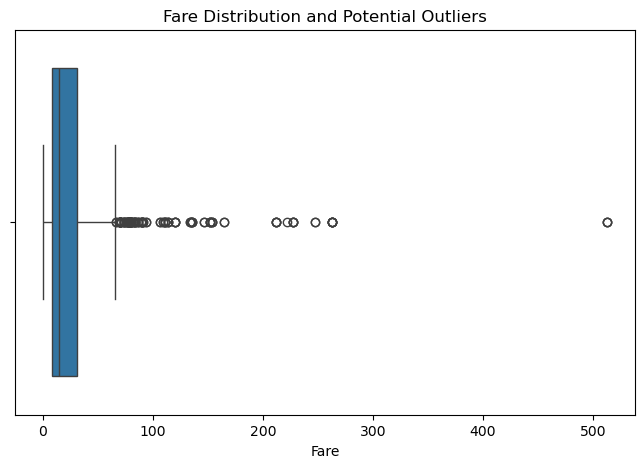

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution and Potential Outliers")
plt.xlabel("Fare")

plt.show()

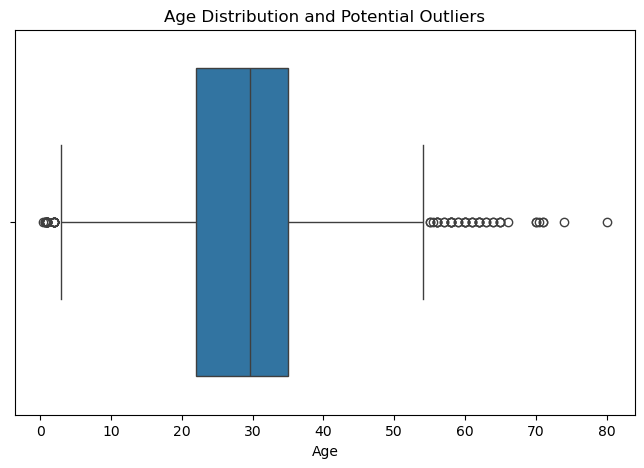

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Age"])

plt.title("Age Distribution and Potential Outliers")
plt.xlabel("Age")

plt.show()

In [46]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [47]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0
